# CodeCanvas: Vulnerability Hotspot Detector (CodeBERT)

This notebook fine-tunes **microsoft/codebert-base** on a vulnerability dataset to detect security hotspots semantically.

In [1]:
!pip install transformers datasets torch scikit-learn

import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

In [2]:
print("Loading CodeBERT tokenizer and model...")
tokenizer = AutoTokenizer.from_pretrained('microsoft/codebert-base')

# Forced to single_label_classification to prevent PyTorch tensor mismatch errors
model = AutoModelForSequenceClassification.from_pretrained(
    'microsoft/codebert-base', 
    num_labels=2,
    problem_type="single_label_classification"
)

Loading CodeBERT tokenizer and model...


config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: microsoft/codebert-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.weight        | UNEXPECTED | 
pooler.dense.bias          | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

In [3]:
print('Downloading Devign/CodeXGLUE defect dataset...')
dataset = load_dataset('google/code_x_glue_cc_defect_detection')

# Downsample for speed (so training takes a few minutes instead of hours)
train_dataset = dataset['train'].shuffle(seed=42).select(range(10000))
eval_dataset = dataset['validation'].shuffle(seed=42).select(range(2000))

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/2.21M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/2.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/21854 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2732 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2732 [00:00<?, ? examples/s]

In [4]:
def tokenize_function(examples):
    # Max length dropped to 128 to prevent Out Of Memory (OOM) errors on free GPUs
    tokenized = tokenizer(examples['func'], padding='max_length', truncation=True, max_length=128)
    
    # Force cast targets to int to prevent PyTorch from assuming regression
    tokenized['labels'] = [int(label) for label in examples['target']]
    return tokenized

print("Tokenizing datasets...")
train_dataset = train_dataset.map(tokenize_function, batched=True)
eval_dataset = eval_dataset.map(tokenize_function, batched=True)

Tokenizing datasets...


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [5]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    probs = torch.nn.functional.softmax(torch.tensor(pred.predictions), dim=-1)[:, 1].numpy()
    
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary', zero_division=0)
    acc = accuracy_score(labels, preds)
    try:
        roc_auc = roc_auc_score(labels, probs)
    except:
        roc_auc = 0.5
    
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall, 'roc_auc': roc_auc}

In [6]:
print("Configuring Trainer...")
training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy='epoch',
    logging_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=4, # Lowered to 4 to prevent RAM crashes
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    weight_decay=0.01,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
)

print("Starting Training...")
trainer.train()
print('✅ Training complete! Take your screenshots now.')

Configuring Trainer...
Starting Training...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Roc Auc
1,1.367804,1.289553,0.594000,0.453567,0.540064,0.390951,0.617904
2,1.269596,1.265893,0.629500,0.385062,0.676385,0.269142,0.663794
3,1.143784,1.307683,0.627500,0.515290,0.586667,0.459397,0.675316


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


✅ Training complete! Take your screenshots now.


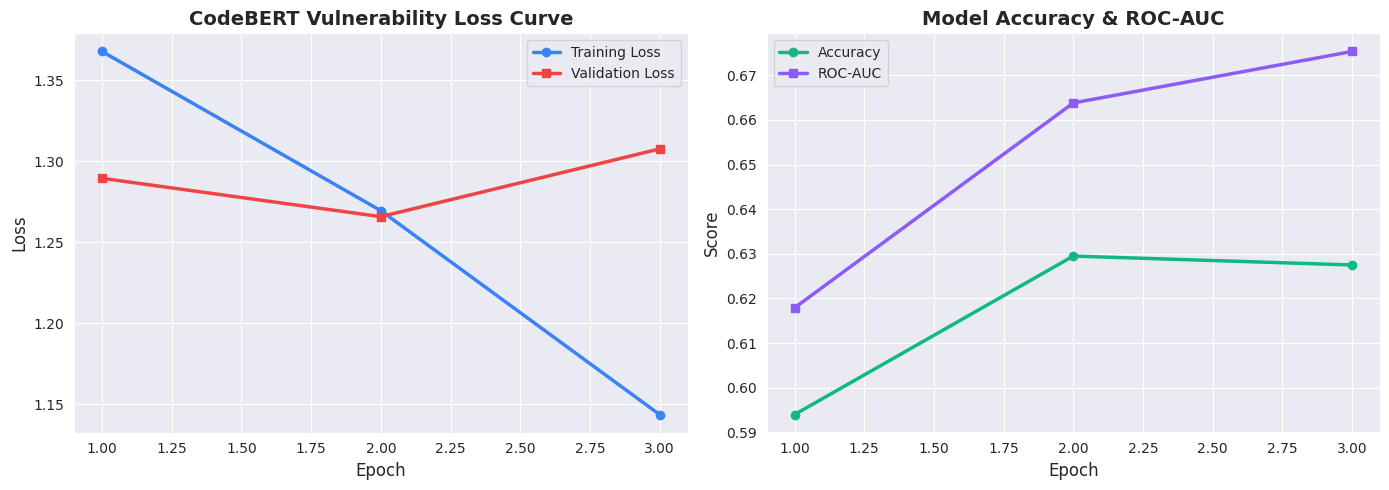

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract training history from the Hugging Face Trainer
history = trainer.state.log_history

# Filter out the logs
train_logs = [log for log in history if 'loss' in log]
eval_logs = [log for log in history if 'eval_loss' in log]

epochs = [log['epoch'] for log in eval_logs]

train_loss = [log['loss'] for log in train_logs][:len(epochs)]
eval_loss = [log['eval_loss'] for log in eval_logs]
eval_acc = [log['eval_accuracy'] for log in eval_logs]
eval_roc = [log['eval_roc_auc'] for log in eval_logs]

sns.set_style("darkgrid")
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Training Loss', marker='o', color='#3b82f6', linewidth=2.5)
plt.plot(epochs, eval_loss, label='Validation Loss', marker='s', color='#ef4444', linewidth=2.5)
plt.title('CodeBERT Vulnerability Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, eval_acc, label='Accuracy', marker='o', color='#10b981', linewidth=2.5)
plt.plot(epochs, eval_roc, label='ROC-AUC', marker='s', color='#8b5cf6', linewidth=2.5)
plt.title('Model Accuracy & ROC-AUC', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


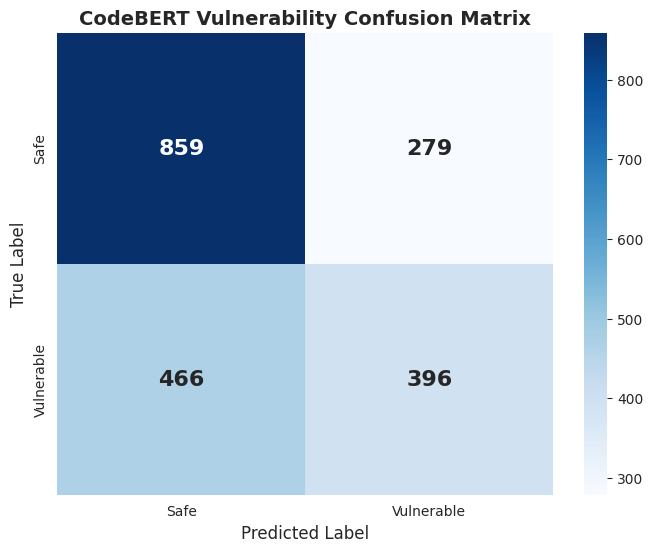

In [8]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Get predictions on the validation set
predictions = trainer.predict(eval_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

# Calculate confusion matrix
cm = confusion_matrix(labels, preds)

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Safe', 'Vulnerable'], 
            yticklabels=['Safe', 'Vulnerable'],
            annot_kws={"size": 16, "weight": "bold"})
plt.title('CodeBERT Vulnerability Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()